<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Подготовка" data-toc-modified-id="Подготовка-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Подготовка</a></span><ul class="toc-item"><li><span><a href="#Загрузка-данных" data-toc-modified-id="Загрузка-данных-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Загрузка данных</a></span></li><li><span><a href="#Предобработка-данных" data-toc-modified-id="Предобработка-данных-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Предобработка данных</a></span></li></ul></li><li><span><a href="#Анализ" data-toc-modified-id="Анализ-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Анализ</a></span></li><li><span><a href="#Обучение" data-toc-modified-id="Обучение-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Обучение</a></span><ul class="toc-item"><li><span><a href="#Подготовка-данных" data-toc-modified-id="Подготовка-данных-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Подготовка данных</a></span></li><li><span><a href="#Обучение-моделей" data-toc-modified-id="Обучение-моделей-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Обучение моделей</a></span></li></ul></li><li><span><a href="#Тестирование" data-toc-modified-id="Тестирование-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Тестирование</a></span></li><li><span><a href="#Общий-вывод" data-toc-modified-id="Общий-вывод-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Общий вывод</a></span></li><li><span><a href="#Чек-лист-проверки" data-toc-modified-id="Чек-лист-проверки-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Чек-лист проверки</a></span></li></ul></div>

In [1]:
#загружаю библиотеки
!pip install matplotlib seaborn scipy lightgbm catboost -q
!pip install --upgrade matplotlib seaborn scikit-learn -q
!pip install phik -q

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import sklearn
import seaborn as sns
import scipy.stats as st
import random
import time
import lightgbm as lgbm

from statsmodels.tsa.seasonal import seasonal_decompose
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.experimental import enable_halving_search_cv  
from sklearn.model_selection import train_test_split, RandomizedSearchCV, HalvingGridSearchCV, cross_validate, cross_val_score
from sklearn.metrics import make_scorer, mean_squared_error
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

#  Прогнозирование заказов такси

Компания «Чётенькое такси» собрала исторические данные о заказах такси в аэропортах. Чтобы привлекать больше водителей в период пиковой нагрузки, нужно спрогнозировать количество заказов такси на следующий час. Постройте модель для такого предсказания.

Значение метрики *RMSE* на тестовой выборке должно быть не больше 48.

Вам нужно:

1. Загрузить данные и выполнить их ресемплирование по одному часу.
2. Проанализировать данные.
3. Обучить разные модели с различными гиперпараметрами. Сделать тестовую выборку размером 10% от исходных данных.
4. Проверить данные на тестовой выборке и сделать выводы.


Данные лежат в файле `taxi.csv`. Количество заказов находится в столбце `num_orders` (от англ. *number of orders*, «число заказов»).

**Цель исследования:** 

Построить модель машинного обучения, которая поможет спрогнозировать количество заказов такси на следующий час. 

**Ход исследования:**

1. Подготовка данных: загрузка и изучение общей информации из датасетов, обработка дубликатов и изменение типов данных, исследовательский анализ данных
2. Анализ данных
2. Обучение моделей
3. Тестирование

**Общий вывод:** резюмирование полученных результатов, формулировка ключевых выводов и рекомендаций

## Подготовка

### Загрузка данных

In [2]:
df_taxi = pd.read_csv('/datasets/taxi.csv')

In [3]:
display(df_taxi.info()) #вывожу общую информацию о датасете

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26496 entries, 0 to 26495
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   datetime    26496 non-null  object
 1   num_orders  26496 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 414.1+ KB


None

In [4]:
display(df_taxi.head()) #вывожу первые строки
display(df_taxi.tail()) #вывожу последние строки

,datetime,num_orders
0,2018-03-01 00:00:00,9
1,2018-03-01 00:10:00,14
2,2018-03-01 00:20:00,28
3,2018-03-01 00:30:00,20
4,2018-03-01 00:40:00,32


,datetime,num_orders
26491,2018-08-31 23:10:00,32
26492,2018-08-31 23:20:00,24
26493,2018-08-31 23:30:00,27
26494,2018-08-31 23:40:00,39
26495,2018-08-31 23:50:00,53


**Вывод:**
В данных df_taxi 26496 строк. Пропусков не обнаружено. Тип столбца datetime указаны неверно

### Предобработка данных

**Изменение типов данных**

In [5]:
df_taxi['datetime'] = pd.to_datetime(df_taxi['datetime'], format='%Y-%m-%d %H:%M:%S')
display(df_taxi.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26496 entries, 0 to 26495
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    26496 non-null  datetime64[ns]
 1   num_orders  26496 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 414.1 KB


None

**Замена индексов на datetime**

In [6]:
df_taxi = df_taxi.set_index('datetime')
print(df_taxi.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB
None


**Ресемплирование**

В хронологическом ли порядке расположены дата и время?

In [7]:
print(df_taxi.index.is_monotonic)

True


Ресемплирование с сумой заказов на каждый час по часам

<Axes: xlabel='datetime'>

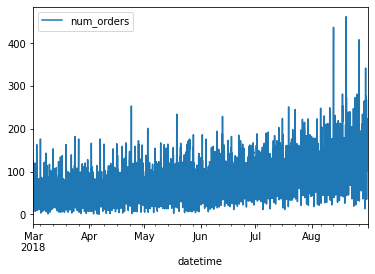

In [8]:
df_taxi = df_taxi.resample('1H').sum()
df_taxi.plot()

**Вывод**

В ходе предобработки данных в датафрейме:
- Столбец datetime приведен к формату datetime64;
- Индексы заменены на столбец datetime;
- Проведено ресемплирование с суммой заказов на каждый час по часам.

## Анализ

In [9]:
date_start = df_taxi.index.min()
date_end = df_taxi.index.max()
all_time = date_end - date_start

print(f'Начальная дата набора данных: {date_start}')
print(f'Конечная дата набора данных: {date_end}')
print(f'Общая продолжительность, охватываемая набором данных: {all_time}')

Начальная дата набора данных: 2018-03-01 00:00:00
Конечная дата набора данных: 2018-08-31 23:00:00
Общая продолжительность, охватываемая набором данных: 183 days 23:00:00


In [10]:
display(df_taxi.describe()) #статистики

,num_orders
count,4416.000000
mean,84.422781
std,45.023853
min,0.000000
25%,54.000000
50%,78.000000
75%,107.000000
max,462.000000


График вызовов по дням:

<Axes: xlabel='datetime'>

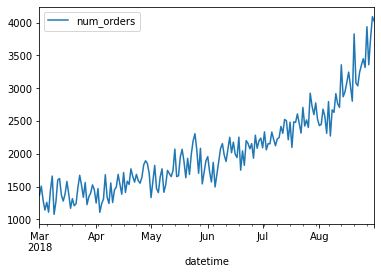

In [11]:
df_taxi_day = df_taxi.resample('1D').sum()
df_taxi_day.plot()

Скользящее среднее с размером окна, равным 10

<Axes: xlabel='datetime'>

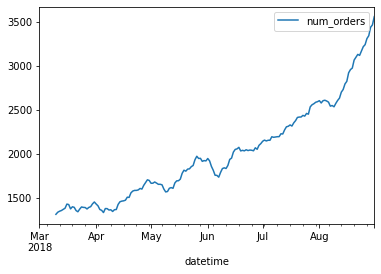

In [12]:
df_taxi_day.rolling(10).mean().plot()

Наблюдается явный тренд к увеличению количества заказов с течением времени

Разложу временной ряд на тренд и сезонную компоненту

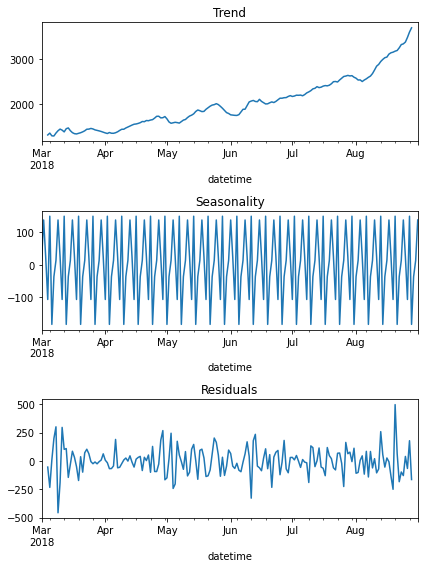

In [13]:
decomposed = seasonal_decompose(df_taxi_day) 

plt.figure(figsize=(6, 8))
plt.subplot(311)
# Чтобы график корректно отобразился, указываем его
# оси ax, равными plt.gca() (англ. get current axis,
# получить текущие оси)
decomposed.trend.plot(ax=plt.gca())
plt.title('Trend')
plt.subplot(312)
decomposed.seasonal.plot(ax=plt.gca()) 
plt.title('Seasonality')
plt.subplot(313)
decomposed.resid.plot(ax=plt.gca()) 
plt.title('Residuals')
plt.tight_layout()

Имеется общий восходящий тренд с увеличением значений в течение времени.Это может указывать на рост популярности сервиса такси или увеличение числа пользователей.
Колебания очень регулярные и имеют схожий характер.
Остатки колеблются вокруг нуля, однако иногда появляются более выраженные отклонения.

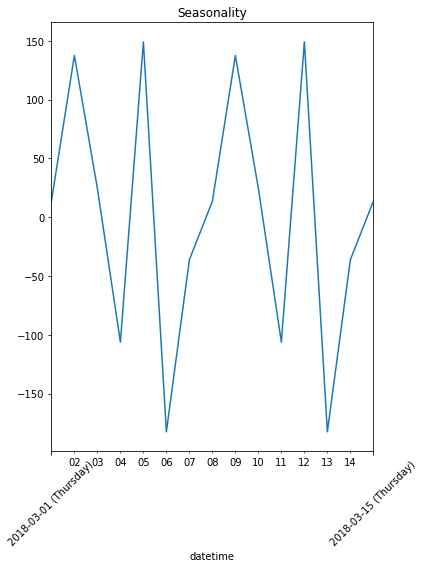

In [14]:
plt.figure(figsize=(6, 8))
decomposed.seasonal['2018-03-01':'2018-03-15'].plot(ax=plt.gca())
plt.title('Seasonality')
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d (%A)'))
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

Частота вызовов такси плавно увеличивается с понедельника по пятницу. В субботу наблюдается резкое падение и локальный пик в ночь с воскресенья на понедельник.

In [15]:
#df_taxi = df_taxi.resample('1H').sum()

decomposed = seasonal_decompose(df_taxi)

Text(0.5, 1.0, 'Seasonality')

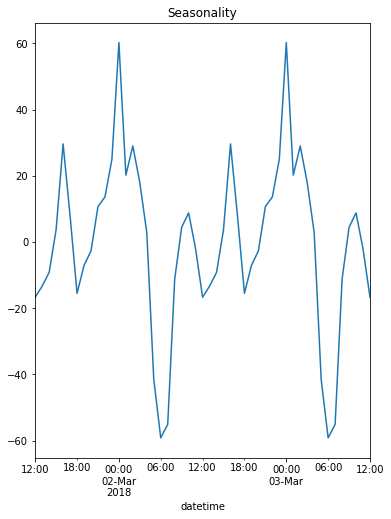

In [16]:
plt.figure(figsize=(6, 8))
decomposed.seasonal['2018-03-01 12:00:00':'2018-03-3 12:00:00'].plot(ax=plt.gca()) 
plt.title('Seasonality')

Количество вызовов всегда резко увеличивается в районе полуночи.

<Axes: xlabel='datetime'>

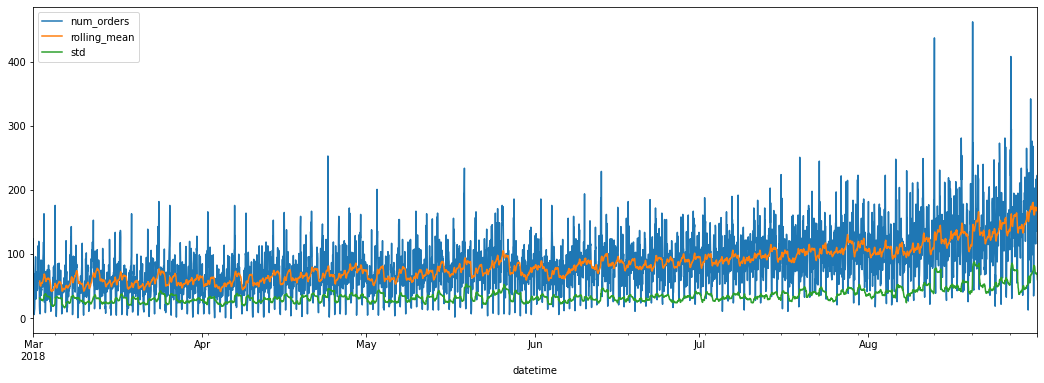

In [17]:
df_plot = df_taxi.copy()
df_plot['rolling_mean'] = df_plot.rolling(30).mean()
df_plot['std'] = df_plot['num_orders'].rolling(30).std()
df_plot.plot(figsize=(18, 6))

Линия, представляющая скользящее среднее, сглаживает колебания данных и позволяет лучше видеть общий тренд. Это помогает понять, что несмотря на прирост вызовов, могут быть сезонные колебания. Судя по области стандартного отклонения данные стабильны.

**Вывод**

Имеется общий восходящий тренд с увеличением значений в течение времени.Это может указывать на рост популярности сервиса такси или увеличение числа пользователей. Частота вызовов такси плавно увеличивается с понедельника по пятницу. В субботу наблюдается резкое падение и локальный пик в ночь с воскресенья на понедельник.Количество вызовов всегда резко увеличивается в районе полуночи.

## Обучение

Для обучения модели выберу следующие регрессоры:

- LinearRegression
- DecisionTreeRegressor
- CatBoostRegressor
- LGBMRegressor

В качестве метрики для оценки всех моделей будет использоваться корень из среднеквадратичной ошибки (RMSE). Для проверки качества моделей будет применяться кросс-валидация.

### Подготовка данных

In [18]:
def make_features(data, max_lag, rolling_mean_size):
    data['dayofweek'] = data.index.dayofweek
    data['hour'] = data.index.hour
    
    for lag in range(1, max_lag + 1):
        data['lag_{}'.format(lag)] = data['num_orders'].shift(lag)

    data['rolling_mean'] = data['num_orders'].shift().rolling(rolling_mean_size).mean()
    data = data.dropna()

In [19]:
make_features(df_taxi, 24, 100)

In [20]:
display(df_taxi.head())

,num_orders,dayofweek,hour,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,...,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,rolling_mean
datetime,,,,,,,,,,,,,,,,,,,,,
2018-03-01 00:00:00,124,3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 01:00:00,85,3,1,124.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 02:00:00,71,3,2,85.0,124.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 03:00:00,66,3,3,71.0,85.0,124.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 04:00:00,43,3,4,66.0,71.0,85.0,124.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
df_taxi = df_taxi.dropna()
display(df_taxi.head())

,num_orders,dayofweek,hour,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,...,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,rolling_mean
datetime,,,,,,,,,,,,,,,,,,,,,
2018-03-05 04:00:00,34,0,4,51.0,32.0,176.0,86.0,68.0,83.0,75.0,...,30.0,41.0,19.0,39.0,39.0,12.0,11.0,22.0,27.0,56.46
2018-03-05 05:00:00,16,0,5,34.0,51.0,32.0,176.0,86.0,68.0,83.0,...,30.0,30.0,41.0,19.0,39.0,39.0,12.0,11.0,22.0,55.56
2018-03-05 06:00:00,3,0,6,16.0,34.0,51.0,32.0,176.0,86.0,68.0,...,56.0,30.0,30.0,41.0,19.0,39.0,39.0,12.0,11.0,54.87
2018-03-05 07:00:00,14,0,7,3.0,16.0,34.0,51.0,32.0,176.0,86.0,...,58.0,56.0,30.0,30.0,41.0,19.0,39.0,39.0,12.0,54.19
2018-03-05 08:00:00,31,0,8,14.0,3.0,16.0,34.0,51.0,32.0,176.0,...,64.0,58.0,56.0,30.0,30.0,41.0,19.0,39.0,39.0,53.67


Разбиваю датасет на обучающую и тестовую выборки в соотношении 9:1

In [22]:
train, test = train_test_split(df_taxi, shuffle=False, test_size=0.1)

X_train = train.drop(['num_orders'], axis=1)
y_train = train['num_orders']
X_test = test.drop(['num_orders'], axis=1)
y_test = test['num_orders']

In [23]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(3884, 27)
(432, 27)
(3884,)
(432,)


**Вывод**

В таблицу добавлены признаки: день недели и час. Выборка разделена на тренировочную и тестовую для проверки качества предсказания моделей. 

### Обучение моделей

In [24]:
def illustration_target(test, predict):
    model_data = pd.DataFrame({"target":test, "predict":predict})
    model_data.plot(figsize=(18, 6))

In [25]:
def train_model(model, X, y, results_df, param_grid=None):
    start = time.time()

    if param_grid:  # Если есть сетка гиперпараметров
        halving_grid_cv = HalvingGridSearchCV(
            model, 
            param_grid, 
            factor=2,  # Уменьшает количество моделей вдвое на каждом этапе
            cv=5, 
            n_jobs=-1,
            scoring='neg_root_mean_squared_error', 
            return_train_score=True
        )
        halving_grid_cv.fit(X, y)
        best_model = halving_grid_cv.best_estimator_
        training_time = halving_grid_cv.cv_results_['mean_fit_time'][halving_grid_cv.best_index_]
        mean_score_time = halving_grid_cv.cv_results_['mean_score_time'][halving_grid_cv.best_index_]
        cross_val_rmse = -cross_val_score(best_model, X, y, scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1).mean()
    else:  # Если гиперпараметры не подбираются
        cv_results = cross_validate(model, X, y, cv=5,
                                    scoring='neg_root_mean_squared_error', return_train_score=False,
                                    n_jobs=-1)
        training_time = np.mean(cv_results['fit_time'])
        mean_score_time = np.mean(cv_results['score_time'])
        model.fit(X, y)
        best_model = model
        cross_val_rmse = -np.mean(cv_results['test_score'])

    # Обучаем модель для предсказаний
    predictions = best_model.predict(X)
    rmse_train = np.sqrt(mean_squared_error(y, predictions))

    # Визуализация результатов
    illustration_target(y, predictions)

    result_row = {
        'Model': best_model.__class__.__name__,
        'Training Time': training_time,
        'Mean Score Time': mean_score_time,
        'RMSE': rmse_train,
        'Cross-Validation RMSE': cross_val_rmse
    }

    results_df = pd.concat([results_df, pd.DataFrame([result_row])], ignore_index=True)

    print('Гиперпараметры модели:\n', best_model.get_params())
    print('RMSE модели равен:', rmse_train)

    return training_time, rmse_train, best_model, cross_val_rmse, results_df

In [26]:
results_df = pd.DataFrame(columns=['Model', 'Training Time', 'Mean Score Time', 'RMSE', 'Cross-Validation RMSE'])

**LinearRegression**

Гиперпараметры модели:
 {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}
RMSE модели равен: 25.83218442158192


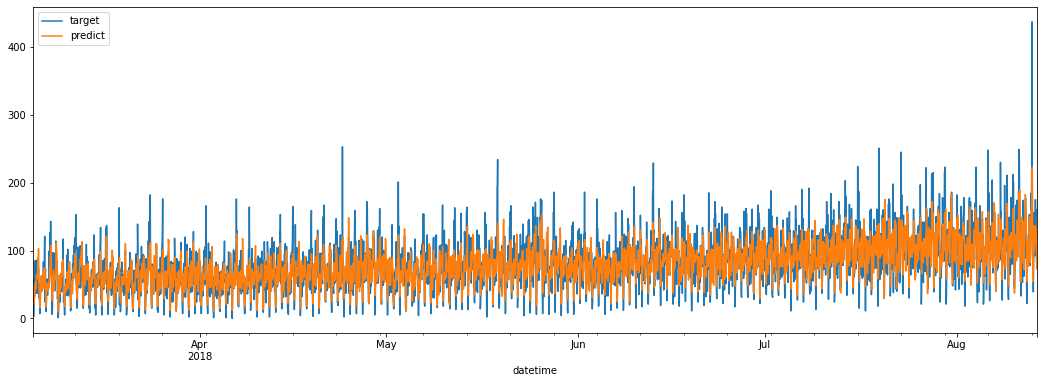

In [27]:
linear_model = LinearRegression()
linear_param_grid = { }  # У LinearRegression нет гиперпараметров для подбора.
training_time_lr, rmse_train_lr, best_model_lr, cross_val_rmse_lr, results_df = train_model(linear_model, X_train, y_train, results_df, param_grid=linear_param_grid)

**DecisionTreeRegressor**

Гиперпараметры модели:
 {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 5, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 10, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}
RMSE модели равен: 24.962754005611163


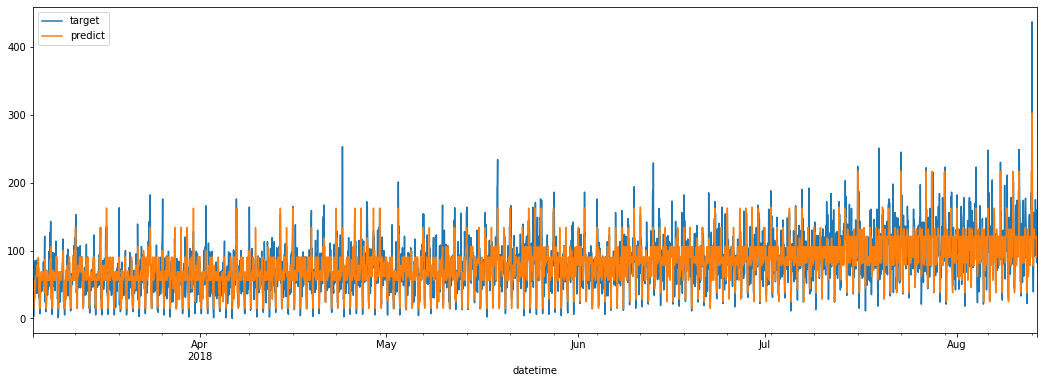

In [28]:
decision_tree_model = DecisionTreeRegressor()
decision_tree_param_grid = {
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
training_time_dt, rmse_train_dt, best_model_dt, cross_val_rmse_dt, results_df = train_model(decision_tree_model, X_train, y_train, results_df, param_grid=decision_tree_param_grid)

**CatBoostRegressor**

Гиперпараметры модели:
 {'loss_function': 'RMSE', 'silent': True, 'depth': 6, 'learning_rate': 0.03}
RMSE модели равен: 14.118127668163552


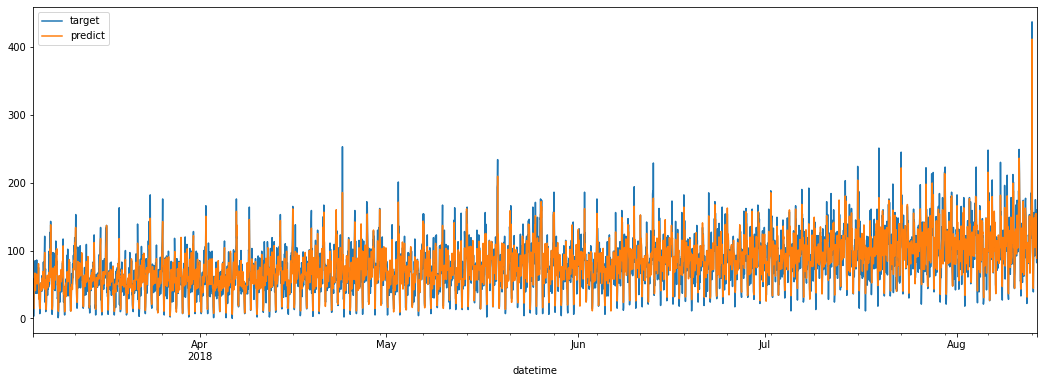

In [29]:
catboost_model = CatBoostRegressor(silent=True)
catboost_param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.03, 0.1],
}
training_time_cb, rmse_train_cb, best_model_cb, cross_val_rmse_cb, results_df = train_model(catboost_model, X_train, y_train, results_df, param_grid=catboost_param_grid)

**LightGBM**

Гиперпараметры модели:
 {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0, 'importance_type': 'split', 'learning_rate': 0.05, 'max_depth': -1, 'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 40, 'n_jobs': -1, 'num_leaves': 31, 'objective': None, 'random_state': None, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'silent': 'warn', 'subsample': 1.0, 'subsample_for_bin': 200000, 'subsample_freq': 0}
RMSE модели равен: 20.45353106111128


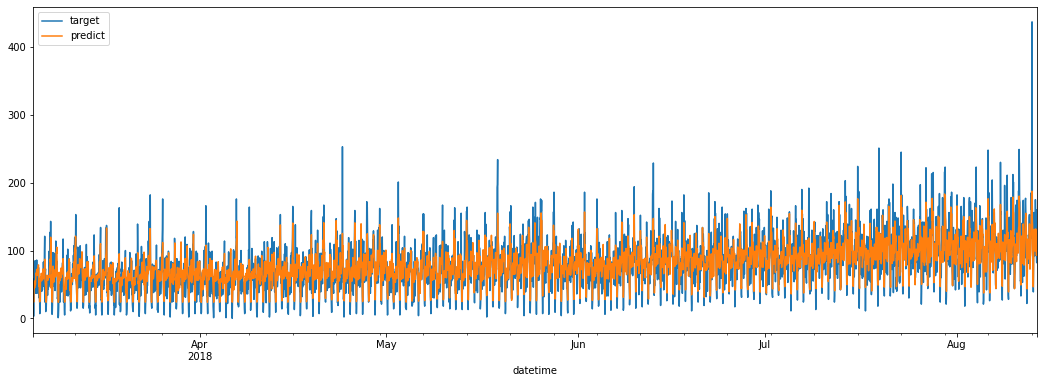

In [30]:
lgbm_model = LGBMRegressor()
lgbm_param_grid = {
    'num_leaves': [31, 50],
    'max_depth': [-1, 5],
    'learning_rate': [0.01, 0.05],
    'n_estimators': [20, 40]
}
training_time_lgbm, rmse_train_lgbm, best_model_lgbm, cross_val_rmse_lgbm, results_df = train_model(lgbm_model, X_train, y_train, results_df, param_grid=lgbm_param_grid)

In [31]:
display(results_df)

,Model,Training Time,Mean Score Time,RMSE,Cross-Validation RMSE
0,LinearRegression,0.094823,0.103075,25.832184,25.833368
1,DecisionTreeRegressor,0.028499,0.003244,24.962754,28.385254
2,CatBoostRegressor,6.871028,0.004420,14.118128,22.790081
3,LGBMRegressor,0.557111,0.057726,20.453531,24.982411


**Вывод**

Если ориентироваться на качество предсказания, то лучшей моделью следует считать CatBoostRegressor с гиперпараметрами {'loss_function': 'RMSE', 'silent': True, 'depth': 6, 'learning_rate': 0.03}

## Тестирование

RMSE = 40.37040815263738


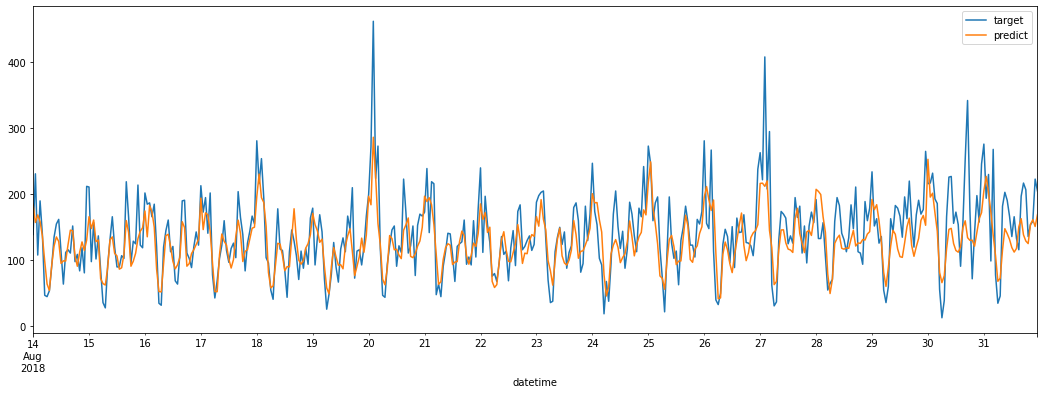

In [32]:
# Предсказание на тестовых данных
predictions = best_model_cb.predict(X_test)

print(f'RMSE = {np.sqrt(np.mean((y_test - predictions) ** 2))}') 

# Визуализация
illustration_target(y_test, predictions)

**Вывод**
На тестовой выборке модель показывает хорошую метрику RMSE = 40.37040815263738

## Общий вывод

В ходе данного исследования было необходимо построить модель машинного обучения, ккоторая поможет спрогнозировать количество заказов такси на следующий час.

Работа состояла из нескольких этапов:
1. Подготовка данных: 
- Столбец datetime приведен к формату datetime64;
- Индексы заменены на столбец datetime;
- Проведено ресемплирование с суммой заказов на каждый час по часам.

2. Анализ данных
- Имеется общий восходящий тренд с увеличением значений в течение времени.Это может указывать на рост популярности сервиса такси или увеличение числа пользователей. Частота вызовов такси плавно увеличивается с понедельника по пятницу. В субботу наблюдается резкое падение и локальный пик в ночь с воскресенья на понедельник.Количество вызовов всегда резко увеличивается в районе полуночи.

3. Обучение моделей
- В таблицу добавлены признаки: день недели и час. Выборка разделена на тренировочную и тестовую для проверки качества предсказания моделей;
- Для обучения модели выбраны следующие регрессоры:

  - LinearRegression
  - DecisionTreeRegressor
  - CatBoostRegressor
  - LGBMRegressor

- Если ориентироваться на качество предсказания, то лучшей моделью следует считать CatBoostRegressor с гиперпараметрами {'loss_function': 'RMSE', 'silent': True, 'depth': 6, 'learning_rate': 0.03}

3. Тестирование:
- На тестовой выборке модель CatBoostRegressor показывает хорошую метрику RMSE = 40.37040815263738 